# here is to plot the stuff

In [1]:
from metamers.eeg.ssvep_plotting import *
from metamers.behavioral.plotting import load_behavior_table

npz_root = "/home/zevaz/projects/metamers/eeg/ssveps"

df = load_metadata(npz_root)
beh = load_behavior_table()

print(beh.head())
print(df.head())

    SubID     Red   Green  RunNumber  session  PartType       Date  \
0  MET001  2149.0   919.0          1        1         1  10_DEC_24   
1  MET001  1999.0  1038.0          2        1         1  10_DEC_24   
2  MET001  1489.0   777.0          3        1         1  10_DEC_24   
3  MET001  1745.0   997.0          4        1         1  10_DEC_24   
4  MET001  1835.0   875.0          5        1         1  10_DEC_24   

           FolderOrg  
0  S01_Beh_10_DEC_24  
1  S01_Beh_10_DEC_24  
2  S01_Beh_10_DEC_24  
3  S01_Beh_10_DEC_24  
4  S01_Beh_10_DEC_24  
  participant_id  session group subgroup  \
0         MET000        1   CTR      NaN   
1         MET000        2   CTR      NaN   
2         MET001        1   CTR      NaN   
3         MET002        1   CTR      NaN   
4         MET002        2   CTR      NaN   

                                            npz_path  
0  /home/zevaz/projects/metamers/eeg/ssveps/MET00...  
1  /home/zevaz/projects/metamers/eeg/ssveps/MET00...  
2  /home/ze

In [2]:
subIDtouse = "MET040"
df_part = df[df["participant_id"] == subIDtouse]
dfbeh_part = beh[beh["SubID"] == subIDtouse]

dfbeh_part

,SubID,Red,Green,RunNumber,session,PartType,Date,FolderOrg
1357,MET040,1008.0,2380.0,1,1,3,11_MAR_26,S40_Beh_11_MAR_26
1358,MET040,961.0,2332.0,2,1,3,11_MAR_26,S40_Beh_11_MAR_26
1359,MET040,2632.0,8.0,3,1,3,11_MAR_26,S40_Beh_11_MAR_26
1360,MET040,1604.0,1269.0,4,1,3,11_MAR_26,S40_Beh_11_MAR_26
1361,MET040,1527.0,1015.0,5,1,3,11_MAR_26,S40_Beh_11_MAR_26
1362,MET040,2904.0,87.0,6,1,3,11_MAR_26,S40_Beh_11_MAR_26
1363,MET040,2821.0,1894.0,7,1,3,11_MAR_26,S40_Beh_11_MAR_26
1364,MET040,1237.0,1305.0,8,1,3,11_MAR_26,S40_Beh_11_MAR_26
1365,MET040,977.0,1242.0,9,1,3,11_MAR_26,S40_Beh_11_MAR_26
1366,MET040,2992.0,246.0,10,1,3,11_MAR_26,S40_Beh_11_MAR_26


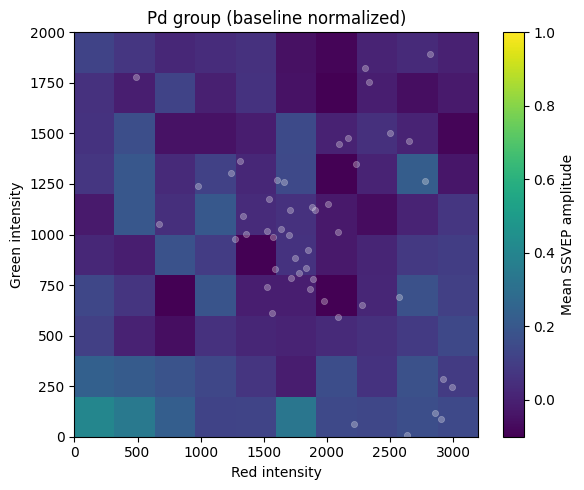

In [3]:
subIDtouse = "MET040"
df_part = df[df["participant_id"] == subIDtouse]
dfbeh_part = beh[beh["SubID"] == subIDtouse]
plot_group_mean_map_with_points(
    df=df_part,
    label="PD",
    normalize=True,
    scatter_df=dfbeh_part,
    scatter_color="#FAF6F5",
    vmin = -0.1,
    vmax = 1,
    ymax = 2000
)

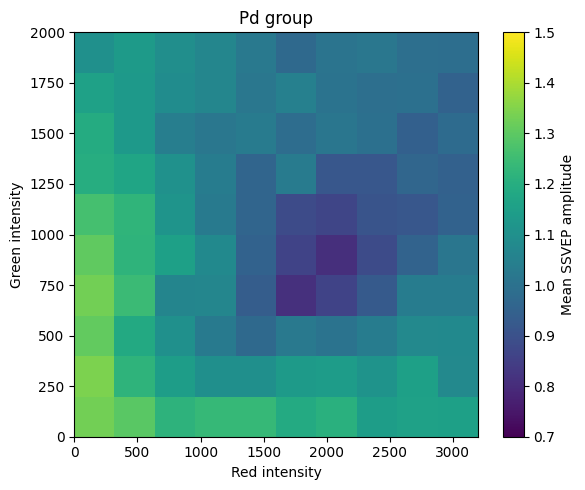

In [4]:
df_PD = beh[beh["PartType"] == 3]

plot_group_mean_map_with_points(
    df=df,
    label="PD",
    normalize=False,
    scatter_color="#FAF6F5",
    vmin = 0.7,
    vmax = 1.5,
    ymax = 2000
)

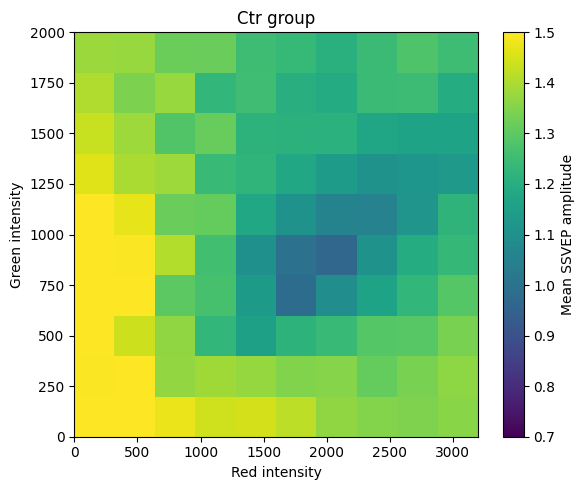

In [5]:
df_HC = beh[beh["PartType"] == 1]

plot_group_mean_map_with_points(
    df=df,
    label="CTR",
    normalize=False,
    scatter_color="#FAF6F5",
    vmin = 0.7,
    vmax = 1.5,
    ymax = 2000
)

In [6]:
def flatten_group_maps(group_meanHC, group_meanPD):
    """
    Convert 10x10 matrices into a tidy DataFrame with 100 values per group.
    """
    hc_vals = group_meanHC.flatten()
    pd_vals = group_meanPD.flatten()

    df = pd.DataFrame({
        "Value": np.concatenate([hc_vals, pd_vals]),
        "Group": ["HC"] * len(hc_vals) + ["PD"] * len(pd_vals)
    })

    return df

import seaborn as sns
import matplotlib.pyplot as plt

def plot_boxplot(df_maps):
    plt.figure(figsize=(6,5))
    sns.boxplot(data=df_maps, x="Group", y="Value", palette=["#4C72B0", "#DD8452"])
    sns.stripplot(data=df_maps, x="Group", y="Value", color="black", alpha=0.3)
    plt.title("Group Comparison — Boxplot")
    plt.tight_layout()
    plt.show()

def plot_violin(df_maps):
    plt.figure(figsize=(6,5))
    sns.violinplot(data=df_maps, x="Group", y="Value", palette=["#4C72B0", "#DD8452"])
    sns.stripplot(data=df_maps, x="Group", y="Value", color="black", alpha=0.25)
    plt.title("Group Comparison — Violin Plot")
    plt.tight_layout()
    plt.show()

def plot_barchart_se(df_maps):
    stats = df_maps.groupby("Group")["Value"].agg(["mean", "std", "count"])
    stats["se"] = stats["std"] / np.sqrt(stats["count"])

    plt.figure(figsize=(6,5))
    plt.bar(stats.index, stats["mean"],
            yerr=stats["se"],
            capsize=6,
            color=["#4C72B0", "#DD8452"])
    plt.ylabel("Mean Value")
    plt.title("Group Comparison — Mean ± SE")
    plt.tight_layout()
    plt.show()

import numpy as np
from scipy.stats import ttest_ind

def pixelwise_ttest(HC_maps, PD_maps):
    HC_stack = np.stack(HC_maps)   # shape: (nHC, 10, 10)
    PD_stack = np.stack(PD_maps)   # shape: (nPD, 10, 10)

    tvals = np.zeros((10,10))
    pvals = np.zeros((10,10))

    for i in range(10):
        for j in range(10):
            hc_vals = HC_stack[:, i, j]
            pd_vals = PD_stack[:, i, j]
            t, p = ttest_ind(hc_vals, pd_vals, equal_var=False)
            tvals[i,j] = t
            pvals[i,j] = p

    return tvals, pvals




/tmp/ipykernel_51049/1086900891.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_maps, x="Group", y="Value", palette=["#4C72B0", "#DD8452"])


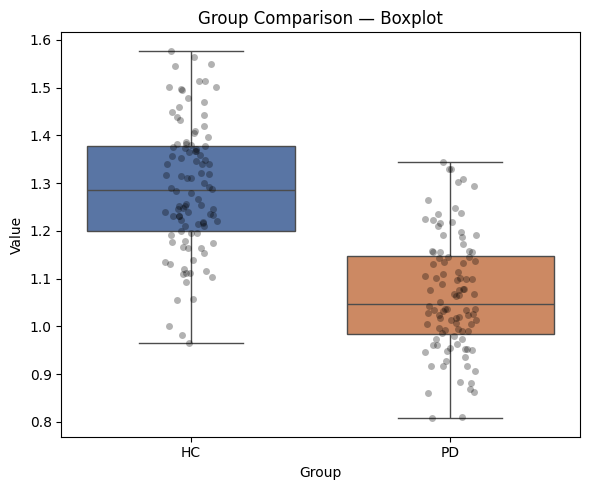

/tmp/ipykernel_51049/1086900891.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_maps, x="Group", y="Value", palette=["#4C72B0", "#DD8452"])


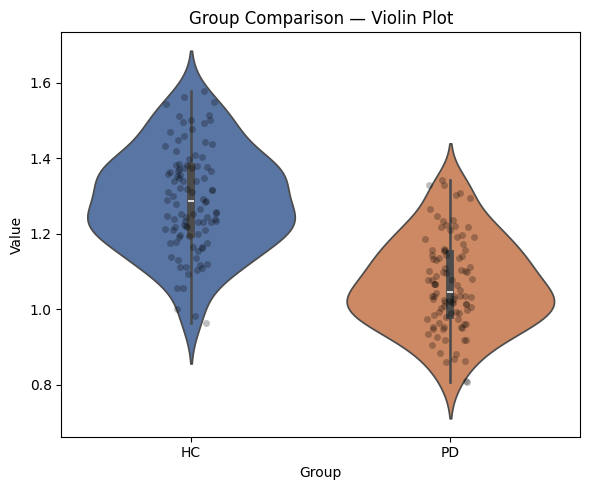

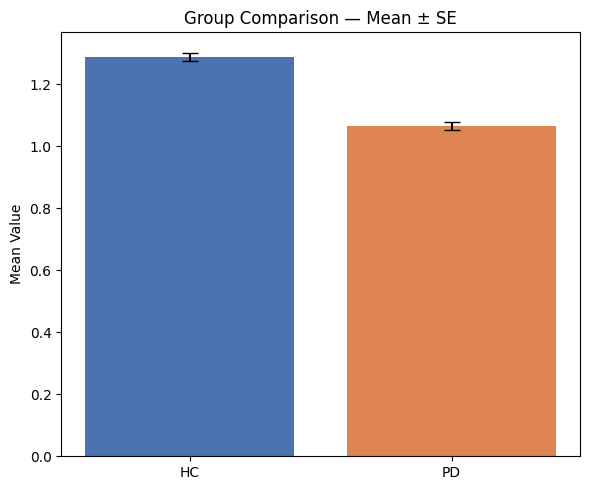

In [7]:
group_meanHC, example = compute_group_mean_map(df=df,
    label="CTR",  normalize=False)
group_meanPD, example = compute_group_mean_map(df=df,
    label="PD",  normalize=False)
df_maps = flatten_group_maps(group_meanHC, group_meanPD)
plot_boxplot(df_maps)
plot_violin(df_maps)
plot_barchart_se(df_maps)

In [17]:
def load_participant_data(df_meta, beh, pid, session):
    """Return EEG NPZ data + behavioral df for a participant."""
    npz_path = df_meta.loc[
        (df_meta["participant_id"] == pid) & (df_meta["session"] == session),
        "npz_path"
    ].iloc[0]

    data = load_ssvep_npz(npz_path)
    df_beh_part = beh[beh["SubID"] == pid]

    return data, df_beh_part

import matplotlib.pyplot as plt
import numpy as np

def get_sessions_for_participant(df_meta, pid):
    """Return sorted list of sessions available for a participant."""
    return sorted(df_meta.loc[df_meta["participant_id"] == pid, "session"].unique())


def plot_participant_grid(
    df_meta,
    beh,
    pids,
    normalize=False,
    runs=None,
    cmap="viridis",
    scatter_color="#000000",
    scatter_size=30,
    cols=4
):
    """
    Plot a grid of participant SSVEP maps (all sessions) with behavioral overlays.
    """
    # Count total number of subplots needed
    total_plots = sum(len(get_sessions_for_participant(df_meta, pid)) for pid in pids)

    rows = int(np.ceil(total_plots / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = axes.flatten()

    plot_idx = 0

    for pid in pids:
        sessions = get_sessions_for_participant(df_meta, pid)
        df_beh_part = beh[beh["SubID"] == pid]

        for session in sessions:
            ax = axes[plot_idx]

            # Load EEG + behavioral
            npz_path = df_meta.loc[
                (df_meta["participant_id"] == pid) &
                (df_meta["session"] == session),
                "npz_path"
            ].iloc[0]

            data = load_ssvep_npz(npz_path)

            # Compute mean map
            mean_map = get_participant_mean_map(data, normalize=normalize, runs=runs)

            # Axes
            red = data["red_array"]
            green = data["green_array"]

            # Plot heatmap
            ax.imshow(
                mean_map,
                origin="lower",
                cmap=cmap,
                extent=[red.min(), red.max(), green.min(), green.max()],
                vmin=0.5,   # lower bound of color scale
                vmax=1.8,
                aspect="auto"
            )

            # Overlay behavioral points
            if len(df_beh_part) > 0:
                ax.scatter(
                    df_beh_part["Red"],
                    df_beh_part["Green"],
                    c=scatter_color,
                    s=scatter_size,
                    edgecolor="white",
                    linewidth=0.5,
                    alpha=0.9
                )

            # Title
            ax.set_title(f"{pid} – Session {session}")
            ax.set_xlabel("Red")
            ax.set_ylabel("Green")
            ax.set_ylim(0, 2000)


            plot_idx += 1

    # Hide unused axes
    for j in range(plot_idx, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()



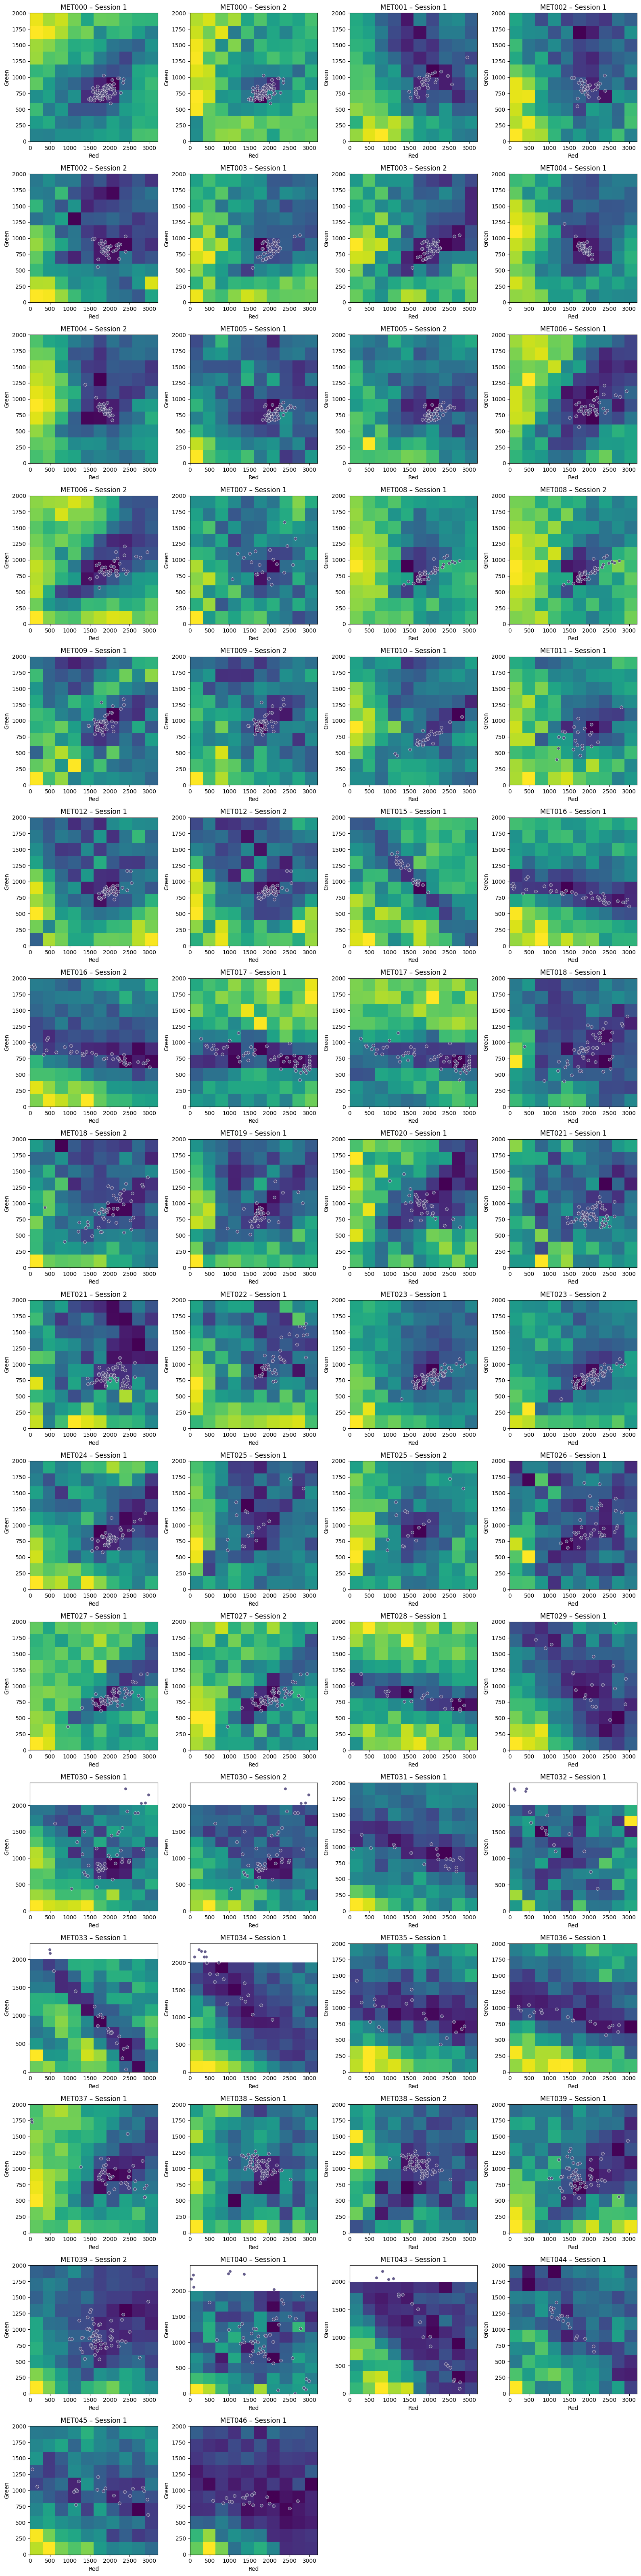

In [15]:
pids = df["participant_id"].unique()
plot_participant_grid(
    df,
    beh,
    pids,
    normalize=True,
    scatter_color="#534b7e"
)

In [ ]:
protans = ["MET016","MET017","MET028","MET031","MET036"]

plot_participant_grid(
    df,
    beh,
    protans,
    normalize=True,
    scatter_color="#ff0000"
)

In [ ]:
deutans = ["MET015", "MET029", "MET032", "MET033", "MET034"]


plot_participant_grid(
    df,
    beh,
    deutans,
    normalize=True,
    scatter_color="#17C234"
)

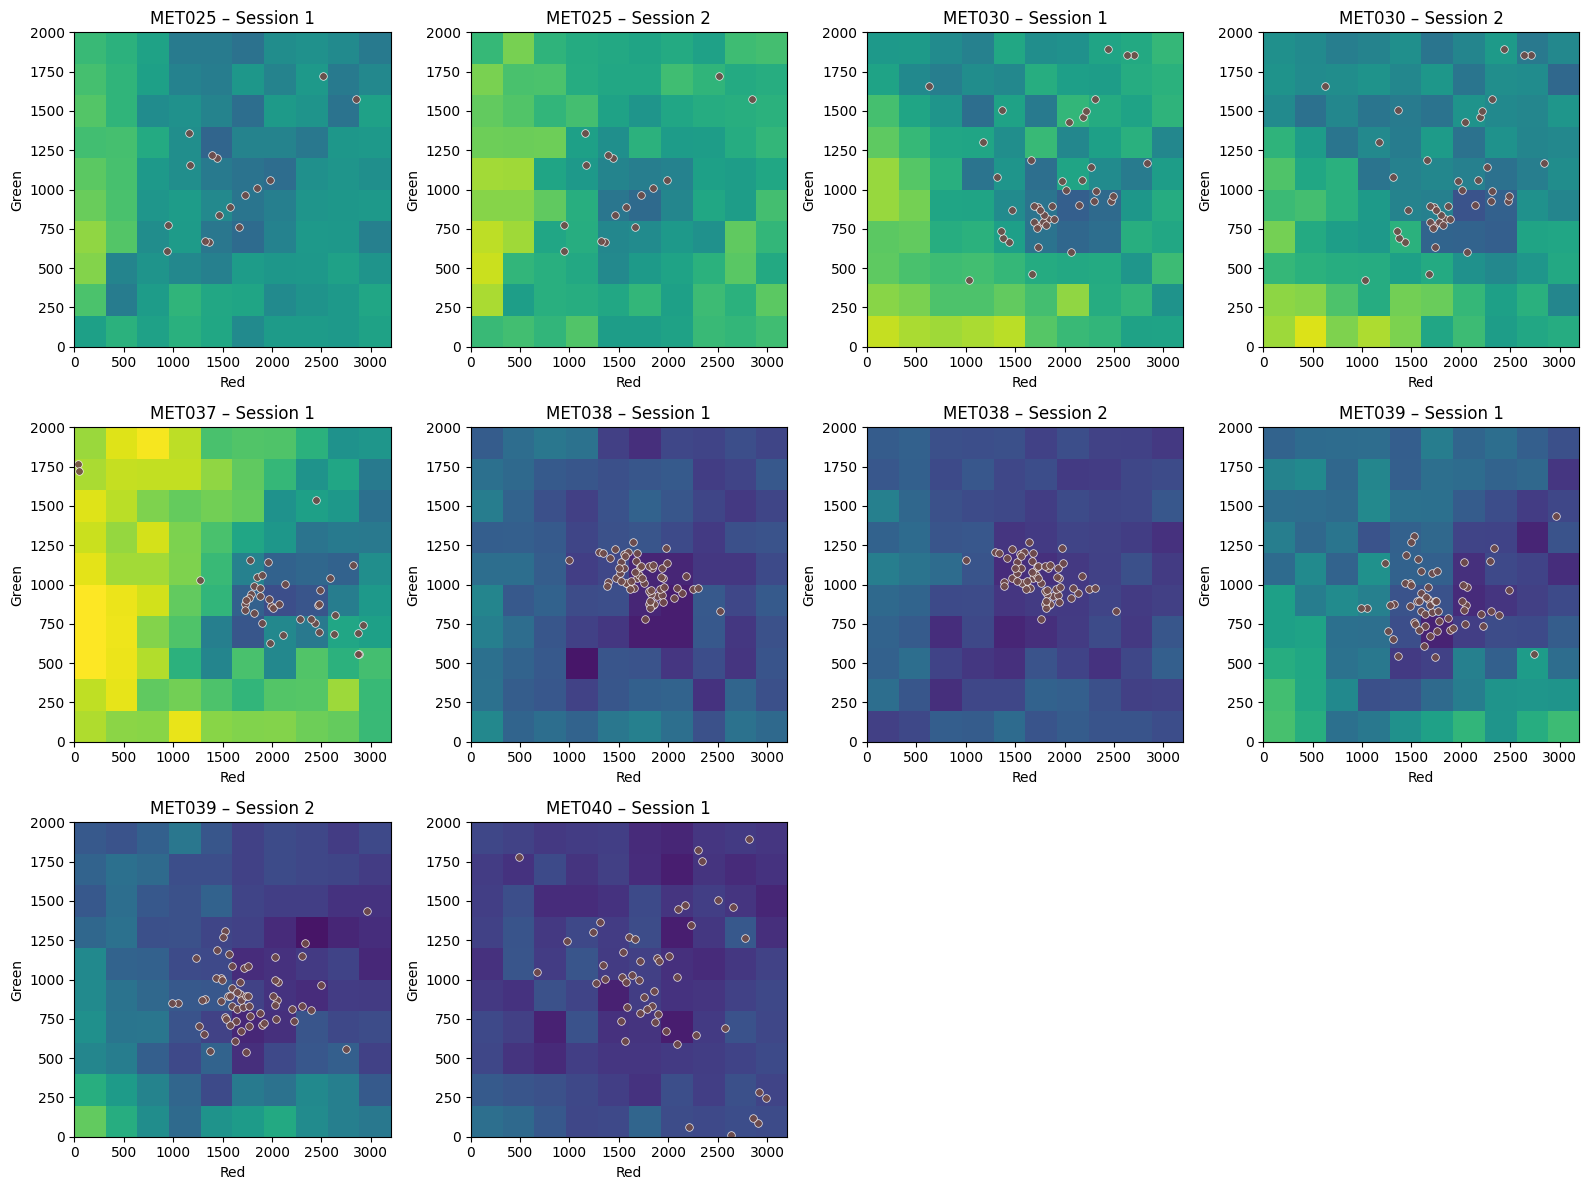

In [18]:
pids_pd = df[df["group"] == "PD"]["participant_id"].unique()

plot_participant_grid(
    df,
    beh,
    pids_pd,
    normalize=False,
    scatter_color="#714b47"
)

In [20]:
vals = np.linspace(0.5, 1.8, 9)
vals

array([0.5   , 0.6625, 0.825 , 0.9875, 1.15  , 1.3125, 1.475 , 1.6375,
       1.8   ])